# fake 품질 필터 검증

In [7]:
%load_ext autoreload
%autoreload 2


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [8]:
import sys
from pathlib import Path
_d = Path.cwd().resolve()
while not (_d / "models.py").exists():
    if _d.parent == _d:
        raise FileNotFoundError("상위 폴더 어디에도 models.py가 없습니다")
    _d = _d.parent
if str(_d) not in sys.path:
    sys.path.insert(0, str(_d))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from torchvision import transforms as T
from torchvision.datasets import ImageFolder
from torchvision.utils import make_grid

from data import build_imbalanced_group_split, FakeQualityFilter

POOL_DIR = _d / "exp1_oversampling_step_10" / "checkpoints"   # exp1이 저장한 fake 풀
POOL_PATH = "exp1_ddpm1000_step{steps}_fake_pool_seed{seed}.pt"
SEEDS_TO_CHECK = [0]   # 한 번만 확인 (seed는 train/test 분할과 fake 풀 파일을 고르는 용도)
STEPS = [10]   # 10스텝 풀만 확인
MINORITY = [1, 2]
FAR_Q = 0.95     # exp3의 FILTER_FAR_Q. 낮추면(0.95 등) 더 엄격

data_root = os.environ.get("DATA_ROOT", "../../data/AM_image_data_3split")
CLASS_NAMES = ["Normal", "Underfill_50FR", "Underfill_Fan"]
train_counts = {0: 800, 1: 80, 2: 80}
test_counts = {0: 100, 1: 100, 2: 100}


## 1. 데이터

In [9]:
transform = T.Compose([
    T.Resize((64, 64)),
    T.ToTensor(),
    T.Lambda(lambda t: (t * 2) - 1),
])
full_dataset = ImageFolder(root=data_root, transform=transform)
assert full_dataset.classes == CLASS_NAMES, full_dataset.classes
all_x = torch.stack([full_dataset[i][0] for i in range(len(full_dataset))])
all_y = torch.tensor([y for _, y in full_dataset.samples])


def train_real(seed):
    tr, _ = build_imbalanced_group_split(full_dataset, train_counts, test_counts, seed=seed)
    return all_x[tr], all_y[tr]


def load_pool(seed, steps):
    path = POOL_DIR / POOL_PATH.format(steps=steps, seed=seed)
    return torch.load(path, map_location="cpu") if path.exists() else None


print("이미지:", tuple(all_x.shape))


이미지: (1965, 3, 64, 64)


## 1-1. 10스텝 fake 풀 만들기

In [10]:
from models import Unet
from utils import set_seed, DEVICE
from diffusion import GaussianDiffusion
from data import generate_balanced_fake

TIMESTEPS = 1000
POOL_PER_CLASS = 800 - 80    # exp1과 동일 (클래스당 720장)
POOL_GEN_BATCH = 360
EMA_PATH = "exp1_ddpm1000_diffusion_ema_seed{seed}.pt"
ddpm = GaussianDiffusion(timesteps=TIMESTEPS, image_size=64, channels=3)


def ensure_pool(seed, steps):
    path = POOL_DIR / POOL_PATH.format(steps=steps, seed=seed)
    if path.exists():
        print(f"[Pool step{steps} seed{seed}] 이미 있음: {path.name}")
        return
    ema_path = POOL_DIR / EMA_PATH.format(seed=seed)
    model = Unet(dim=32, channels=3, num_classes=3).to(DEVICE)
    model.load_state_dict(torch.load(ema_path, map_location=DEVICE))
    model.eval()
    set_seed(seed)   # exp1과 같은 초기 노이즈
    pool = generate_balanced_fake(ddpm, model, DEVICE, steps, target_per_class=POOL_PER_CLASS, minority_classes=tuple(MINORITY),
                                  batch_size=POOL_GEN_BATCH)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(pool, path)
    print(f"[Pool step{steps} seed{seed}] 저장: {path}")


for seed in SEEDS_TO_CHECK:
    for steps in STEPS:
        ensure_pool(seed, steps)


[Pool step10 seed0] 이미 있음: exp1_ddpm1000_step10_fake_pool_seed0.pt


## 2. 제외 비율

In [11]:
rows = []
filters = {}
for seed in SEEDS_TO_CHECK:
    rx, ry = train_real(seed)
    qf = FakeQualityFilter(rx, ry, MINORITY, far_q=FAR_Q)
    filters[seed] = qf
    for steps in STEPS:
        pool = load_pool(seed, steps)
        if pool is None:
            continue
        for c in MINORITY:
            rej = ~qf.accept(pool[c], c)
            rows.append({"seed": seed, "class": CLASS_NAMES[c], "steps": steps,
                         "제외(%)": rej.float().mean().item() * 100, "통과(장)": int((~rej).sum())})
df_rej = pd.DataFrame(rows)
if df_rej.empty:
    found = sorted(p.name for p in POOL_DIR.glob("*fake_pool*")) if POOL_DIR.exists() else "폴더 없음"
    raise FileNotFoundError(f"fake 풀을 못 찾았습니다. 찾은 위치: {POOL_DIR}\n기대 파일명: {POOL_PATH}\n그 폴더의 풀 파일: {found}")
df_rej.round(1)


,seed,class,steps,제외(%),통과(장)
0,0,Underfill_50FR,10,47.9,375
1,0,Underfill_Fan,10,26.8,527


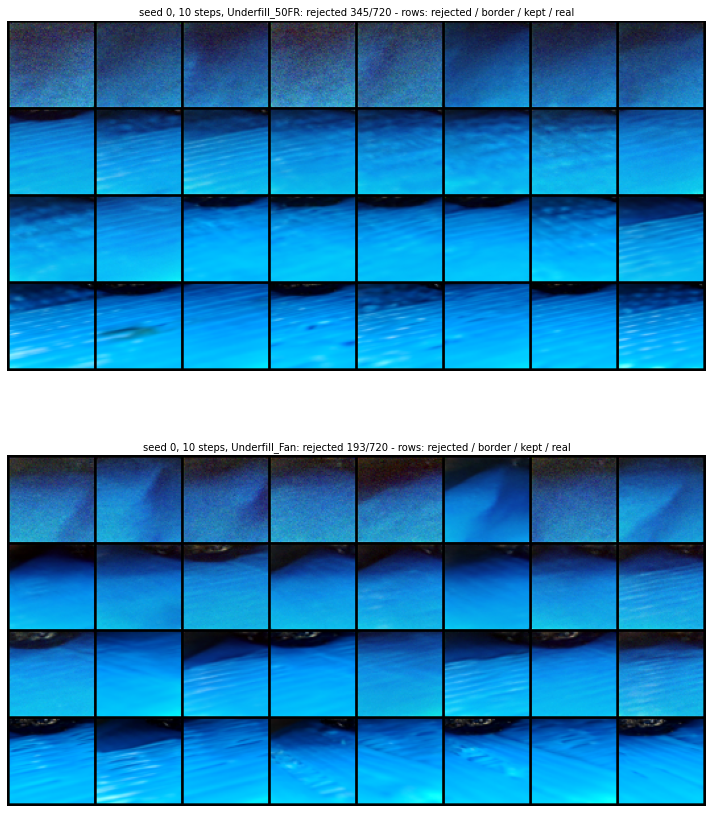

In [12]:
SHOW_SEED = SEEDS_TO_CHECK[0]
SHOW_STEPS = 10
N = 8


def denorm(x):
    return ((x + 1) / 2).clamp(0, 1)


qf = filters[SHOW_SEED]
pool = load_pool(SHOW_SEED, SHOW_STEPS)
rx, ry = train_real(SHOW_SEED)
fig, axes = plt.subplots(len(MINORITY), 1, figsize=(10, 6.2 * len(MINORITY)))
for ax, c in zip(np.atleast_1d(axes), MINORITY):
    x = pool[c]
    dist = qf.dist(x, c)
    badness = dist / qf.t_far[c]   # 기준선 대비 거리 (1 초과 = 제외)
    order = badness.argsort(descending=True)
    n_rej = int((badness > 1).sum())
    worst = x[order[:N]]
    border = x[order[max(0, n_rej - N // 2): max(0, n_rej - N // 2) + N]]
    kept_idx = order[n_rej:]
    kept = x[kept_idx[torch.randperm(len(kept_idx))[:N]]]
    real = rx[ry == c][:N]
    grid = make_grid(denorm(torch.cat([worst, border, kept, real])), nrow=N, padding=2)
    ax.imshow(grid.permute(1, 2, 0))
    ax.axis("off")
    ax.set_title(f"seed {SHOW_SEED}, {SHOW_STEPS} steps, {CLASS_NAMES[c]}: rejected {n_rej}/{len(x)} "
                 f"- rows: rejected / border / kept / real", fontsize=10)
plt.tight_layout()
plt.show()
